# Task 4.2 — Predict HAI Magnitude for H3N2 A/Massachusetts/18/2022 (D28)

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

---

## Design notes

**Proxy target:** The target strain (H3N2 A/Massachusetts/18/2022) is absent from the training data.
We approximate it by averaging the Day 28 HAI titers of all other H3N2 strains present in the dataset.
All HAI columns are then dropped to prevent leakage.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale.
Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [149]:
TARGET_COL = 'H3N2_proxy_d28'  # proxy: target strain absent from training data
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 30

In [150]:
CSV_PATH = '../merged_data/combined.csv'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [151]:
import io
import os
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [152]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_tran = pd.read_csv(CHALLENGE_DATA_PATH + '/transcriptomics_challenge_pca.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
challenge_data = challenge_data.merge(challenge_tran, on='participant_id', how='left')

# Add same HAI aggregate features as training
ch_h3n2_d0 = [c for c in challenge_data.columns if 'H3N2' in c and c.endswith('_d0')]
ch_h1n1_d0 = [c for c in challenge_data.columns if 'H1N1' in c and c.endswith('_d0')]
ch_all_d0   = [c for c in challenge_data.columns if c.startswith('HAI_') and c.endswith('_d0')]

challenge_data['HAI_mean_H3N2_d0']  = challenge_data[ch_h3n2_d0].mean(axis=1)
challenge_data['HAI_mean_H1N1_d0']  = challenge_data[ch_h1n1_d0].mean(axis=1)
challenge_data['HAI_mean_all_d0']   = challenge_data[ch_all_d0].mean(axis=1)
challenge_data['HAI_n_measured_d0'] = challenge_data[ch_all_d0].notna().sum(axis=1)

print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 315)


### Preprocessing — proxy target\n\nThe target strain is absent from the training set. We create a proxy by averaging all H3N2 Day 28 HAI titers.\nRows are filtered to those with a valid proxy target, then all-null columns are removed on the filtered subset.\nThe `_d28`/`_d365` columns are excluded from features at training time to prevent leakage.

In [153]:
df = pd.read_csv(CSV_PATH)
print(f'Raw shape: {df.shape}')

Raw shape: (3757, 489)


In [154]:
# Missing data summary by feature group
missing = df.isna().mean().rename('pct_missing')
missing = missing[missing > 0].sort_values(ascending=False)

def feature_group(col):
    if col.startswith('TRAN_'): return 'TRAN'
    if col.startswith('HAI_'):  return 'HAI'
    if col.startswith('PART_'): return 'PART'
    return 'other'

summary = missing.to_frame()
summary['group'] = summary.index.map(feature_group)
summary['n_missing'] = (missing * len(df)).astype(int)

print("Missing data by group:")
print(summary.groupby('group')['pct_missing'].agg(['count', 'min', 'max', 'mean']).round(3))
print(f"\nTotal columns with any missing: {len(missing)} / {df.shape[1]}")
print(f"\nTop 20 most-missing columns:")
display(summary.head(20))

Missing data by group:
       count    min    max   mean
group                            
HAI      195  0.222  0.993  0.844
TRAN     290  0.895  0.895  0.895

Total columns with any missing: 485 / 489

Top 20 most-missing columns:


,pct_missing,group,n_missing
HAI_Yam B/Brisbane/3/2007_d0,0.992547,HAI,3729
HAI_Yam B/Brisbane/3/2007_d28,0.992547,HAI,3729
HAI_Anc B/Lee/1940_d365,0.983497,HAI,3695
HAI_H1N1 A/Hawaii/70/2019_d28,0.980836,HAI,3685
HAI_H1N1 A/Hawaii/70/2019_d0,0.980570,HAI,3684
HAI_H3N2 A/Victoria/3/1975_d28,0.979239,HAI,3679
HAI_H1N1 A/Puerto Rico/8/1934_d28,0.979239,HAI,3679
HAI_H1N1 A/Puerto Rico/8/1934_d0,0.979239,HAI,3679
HAI_H3N2 A/Victoria/3/1975_d0,0.979239,HAI,3679
HAI_H3N2 A/Sydney/5/1997_d365,0.977908,HAI,3674


In [155]:
# Create proxy target: row-wise average of all H3N2 d28 HAI strains
h3n2_d28_cols = [c for c in df.columns if c.startswith('HAI_') and 'H3N2' in c and c.endswith('_d28')]
df[TARGET_COL] = df[h3n2_d28_cols].mean(axis=1)
print(f'Proxy target averaged from {len(h3n2_d28_cols)} H3N2 d28 strains')

Proxy target averaged from 25 H3N2 d28 strains


In [156]:
# Keep only participants with transcriptomics data
df = df[df['TRAN_PC1'].notna()]
print(f'Rows with transcriptomics: {len(df)}')

# Drop columns that are all-null in this subset
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns → {df.shape[1]} remaining')

# Drop d0 columns that are >50% missing — single-cohort strains not worth imputing
sparse_d0 = [c for c in df.columns if c.endswith('_d0') and df[c].isna().mean() > 0.5]
df = df.drop(columns=sparse_d0)
print(f'Dropped {len(sparse_d0)} sparse d0 columns → {df.shape[1]} remaining')

# Filter to rows with a valid proxy target
df = df[df[TARGET_COL].notna()]
print(f'Rows with valid proxy target: {len(df)}')

Rows with transcriptomics: 395
Dropped 127 all-null columns → 363 remaining
Dropped 5 sparse d0 columns → 358 remaining
Rows with valid proxy target: 394


In [157]:
print(f'Shape: {df.shape}')
print(f'Target stats:\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')
print(f'\nMissing per column (top 10):\n{df.isna().sum().sort_values(ascending=False).head(10)}')

Shape: (394, 358)
Target stats:
count    394.000000
mean       6.261026
std        2.294953
min        2.571928
25%        4.607642
50%        5.821928
75%        7.446928
max       14.321928
Name: H3N2_proxy_d28, dtype: float64

dtype counts:
float64    355
object       3
Name: count, dtype: int64

Missing per column (top 10):
HAI_H3N2 A/Tasmania/503/2020_d365      354
HAI_Vic B/Austria/1359417/2021_d365    354
HAI_H1N1 A/Victoria/2570/2019_d365     354
HAI_H3N2 A/Darwin/9/2021_d365          354
HAI_Vic B/Austria/1359417/2021_d28     346
HAI_H3N2 A/Tasmania/503/2020_d28       346
HAI_H1N1 A/Victoria/2570/2019_d28      346
HAI_H3N2 A/Darwin/9/2021_d28           346
HAI_H1N1 A/Hawaii/70/2019_d28          323
HAI_H1N1 A/Michigan/45/2015_d365       195
dtype: int64


In [158]:
h3n2_d0 = [c for c in df.columns if 'H3N2' in c and c.endswith('_d0')]
h1n1_d0 = [c for c in df.columns if 'H1N1' in c and c.endswith('_d0')]
all_d0   = [c for c in df.columns if c.startswith('HAI_') and c.endswith('_d0')]

df['HAI_mean_H3N2_d0']  = df[h3n2_d0].mean(axis=1)
df['HAI_mean_H1N1_d0']  = df[h1n1_d0].mean(axis=1)
df['HAI_mean_all_d0']   = df[all_d0].mean(axis=1)
df['HAI_n_measured_d0'] = df[all_d0].notna().sum(axis=1)
print(f'Added 4 HAI aggregate features. Shape: {df.shape}')

Added 4 HAI aggregate features. Shape: (394, 362)


---
## AutoML Setup

In [159]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)
  Starting server from C:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\arvin\AppData\Local\Temp\tmpv06b3g1s
  JVM stdout: C:\Users\arvin\AppData\Local\Temp\tmpv06b3g1s\h2o_arvin_started_from_python.out
  JVM stderr: C:\Users\arvin\AppData\Local\Temp\tmpv06b3g1s\h2o_arvin_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 13 days
H2O_cluster_name:,H2O_from_python_arvin_w97rqq
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.920 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [160]:
print(f'Converting to H2O: {df.shape[0]} rows × {df.shape[1]} columns')
col_types = {c: 'real' for c in df.select_dtypes(include=['number']).columns}
data = h2o.H2OFrame(df, column_types=col_types)
print(f'H2OFrame shape: {data.shape}')

Converting to H2O: 394 rows × 362 columns
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (394, 362)


---
## AutoML Training

In [161]:
# Features: everything available at d0 — exclude all d28/d365 targets and participant_id
x = [c for c in data.columns
     if not c.endswith('_d28') and not c.endswith('_d365')
     and c != 'participant_id']
y = TARGET_COL

train = data[data[y].isna() == 0]
print(f'Training samples: {train.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    seed=1,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS,
    exclude_algos=['DeepLearning', 'GLM'],
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=train)
print('Training complete.')

Training samples: 394  |  Features: 318
Training complete.


In [162]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                    rmse      mse       mae     rmsle    mean_residual_deviance
GBM_grid_1_AutoML_1_20260525_212924_model_90             1.10147  1.21324  0.862664  0.163657                   1.21324
StackedEnsemble_BestOfFamily_6_AutoML_1_20260525_212924  1.1048   1.22059  0.861787  0.162803                   1.22059
GBM_grid_1_AutoML_1_20260525_212924_model_244            1.11145  1.23532  0.870705  0.165706                   1.23532
GBM_grid_1_AutoML_1_20260525_212924_model_368            1.11227  1.23713  0.878229  0.16556                    1.23713
GBM_grid_1_AutoML_1_20260525_212924_model_58             1.1129   1.23856  0.869903  0.165653                   1.23856
GBM_grid_1_AutoML_1_20260525_212924_model_84             1.11447  1.24205  0.869326  0.164645                   1.24205
GBM_grid_1_AutoML_1_20260525_212924_model_297            1.11505  1.24335  0.871268  0.165034                   1.24335
GBM_grid_1_AutoML_1_20260525_212924_mode

In [163]:
# Stacked Ensembles don't store CV predictions — fall back to best base model if needed
model = aml.leader
if model.cross_validation_holdout_predictions() is None:
    for m_id in aml.leaderboard['model_id'].as_data_frame()['model_id']:
        m = h2o.get_model(m_id)
        if m.cross_validation_holdout_predictions() is not None:
            model = m
            break

cv_preds = model.cross_validation_holdout_predictions().as_data_frame()['predict']
actuals = train[y].as_data_frame()[y]
rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.2 — Spearman (5-fold CV): {rho:.3f}  (p={pval:.4f})')
print(f'Model used for eval: {model.model_id}')

Task 4.2 — Spearman (5-fold CV): 0.815  (p=0.0000)
Model used for eval: GBM_grid_1_AutoML_1_20260525_212924_model_90


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


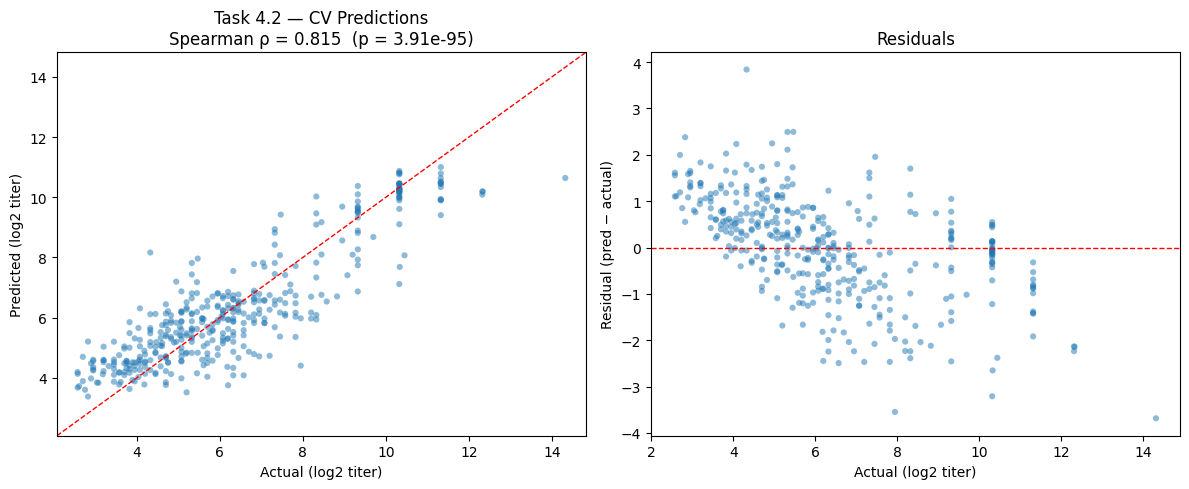

In [164]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: actual vs predicted (log2 space)
ax = axes[0]
ax.scatter(actuals, cv_preds, alpha=0.5, s=20, edgecolors='none')
lim = [min(actuals.min(), cv_preds.min()) - 0.5,
       max(actuals.max(), cv_preds.max()) + 0.5]
ax.plot(lim, lim, 'r--', linewidth=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual (log2 titer)')
ax.set_ylabel('Predicted (log2 titer)')
ax.set_title(f'Task 4.2 — CV Predictions\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})')

# Residuals
ax = axes[1]
residuals = cv_preds.values - actuals.values
ax.scatter(actuals, residuals, alpha=0.5, s=20, edgecolors='none')
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Actual (log2 titer)')
ax.set_ylabel('Residual (pred − actual)')
ax.set_title('Residuals')

plt.tight_layout()
plt.show()

Leader model: GBM_grid_1_AutoML_1_20260525_212924_model_90
Varimp model: GBM_grid_1_AutoML_1_20260525_212924_model_90


,variable,relative_importance,scaled_importance,percentage
0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,3624.997314,1.000000,0.350264
1,HAI_mean_H3N2_d0,2288.137939,0.631211,0.221091
2,HAI_H3N2 A/South Australia/34/2019_d0,1682.518555,0.464143,0.162573
3,HAI_mean_all_d0,206.392776,0.056936,0.019943
4,PART_age,93.300919,0.025738,0.009015
5,HAI_H3N2 A/Texas/50/2012_d0,64.091171,0.017680,0.006193
6,HAI_H1N1 A/Brisbane/2/2018_d0,60.502522,0.016690,0.005846
7,TRAN_PC178,54.619961,0.015068,0.005278
8,TRAN_PC211,53.955902,0.014884,0.005213
9,HAI_H3N2 A/Panama/2007/1999_d0,47.295609,0.013047,0.004570


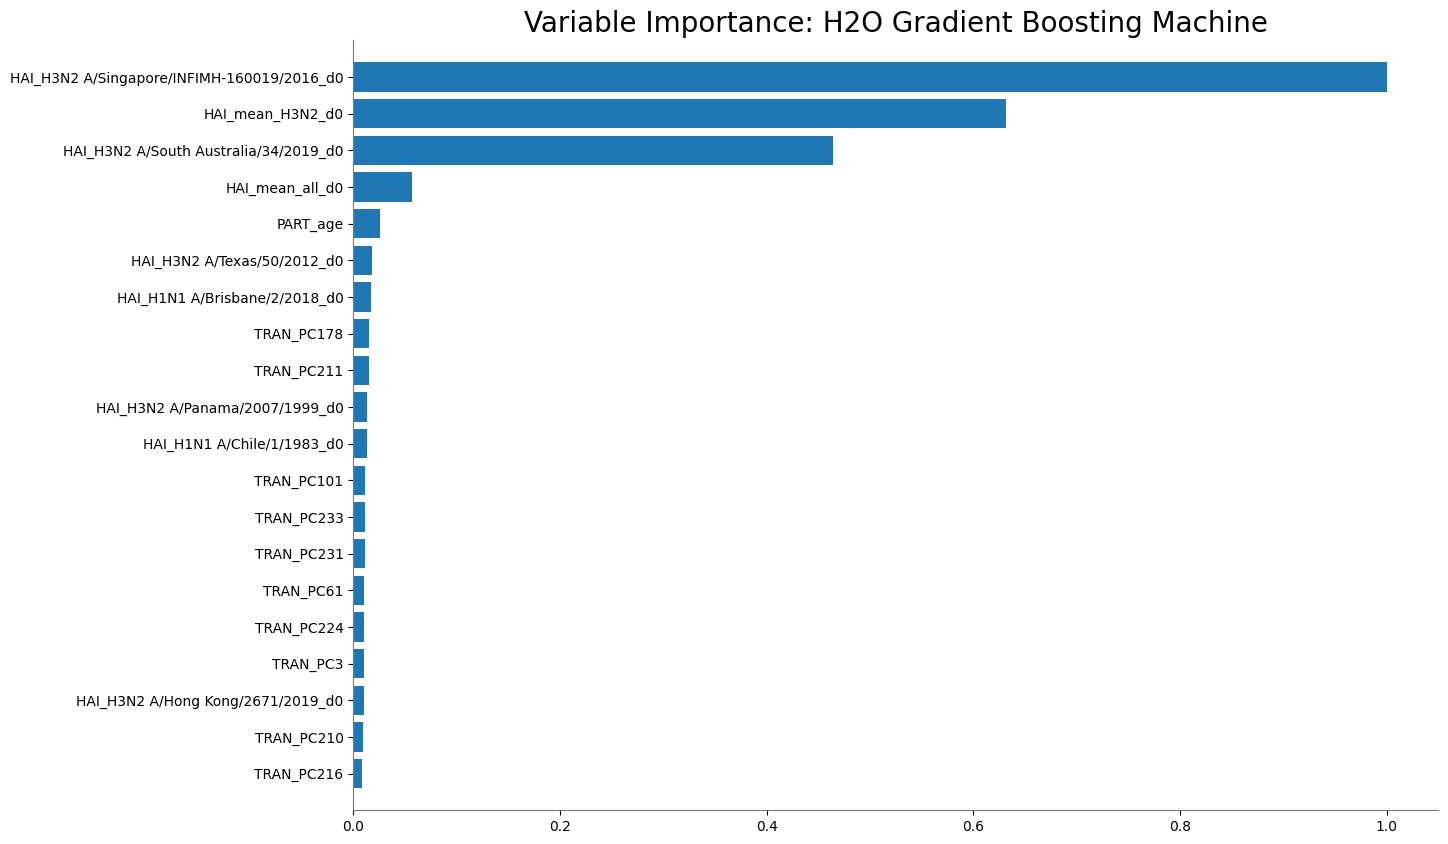

<Figure size 640x480 with 0 Axes>

In [165]:
print(f'Leader model: {aml.leader.model_id}')
print(f'Varimp model: {model.model_id}')
varimp = model.varimp(use_pandas=True)
display(varimp.head(20))
model.varimp_plot(num_of_features=20)

In [166]:
challenge_col_types = {c: 'real' for c in challenge_data.select_dtypes(include=['number']).columns}
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)

y_pred = aml.leader.predict(challenge_hf).as_data_frame()['predict']

os.makedirs(SUBMISSION_PATH, exist_ok=True)
results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.2': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_2.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.2
0,2024_UGA.ID_077,20.344177
1,2024_UGA.ID_086,20.426147
2,2024_UGA.ID_128,170.437417
3,2024_UGA.ID_170,28.189993
4,2024_UGA.ID_179,39.104515
5,2024_UGA.ID_215,116.628050
6,2024_UGA.ID_219,26.401176
7,2024_UGA.ID_275,13.737272
8,2024_UGA.ID_295,28.104881
9,2024_UGA.ID_296,15.051044


In [167]:
# Capture H2O-dependent values before shutdown
_leader_model_id = lb[0, 'model_id']
_n_training_rows = train.nrows
_n_models = lb.nrows

In [168]:
h2o.cluster().shutdown()

H2O session _sid_9284 closed.
